In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import pickle
import missingno as msno 

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.neighbors import KNeighborsClassifier as KNNC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB


In [2]:
tesla = yf.download(
    "TSLA",
    start="2020-01-01",
    end=None   # Automatically fetch till today
)

tesla.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [3]:
# 1. Remove multi-level columns (removes TSLA / Ticker level)
tesla.columns = tesla.columns.get_level_values(0)

# 2. Remove index name "Ticker" if present
tesla.index.name = None

# 3. Remove any row named 'Ticker' (if it exists)
tesla = tesla[tesla.index != 'Ticker']

# 4. Reset index (clean structure)
tesla.reset_index(drop=True, inplace=True)

# ✅ Check final dataset
print(tesla.head())

Price      Close       High        Low       Open     Volume
0      28.684000  28.713333  28.114000  28.299999  142981500
1      29.534000  30.266666  29.128000  29.366667  266677500
2      30.102667  30.104000  29.333332  29.364668  151995000
3      31.270666  31.441999  30.224001  30.760000  268231500
4      32.809334  33.232666  31.215334  31.580000  467164500


In [4]:
tesla = yf.download(
    "TSLA",
    start="2020-01-01",
    end=None   # Automatically fetch till today
)

tesla.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [5]:
print ("The shape of the  data is (row, column):"+ str(tesla.shape))

The shape of the  data is (row, column):(1568, 5)


In [6]:
print (tesla.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1568 entries, 2020-01-02 to 2026-03-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1568 non-null   float64
 1   (High, TSLA)    1568 non-null   float64
 2   (Low, TSLA)     1568 non-null   float64
 3   (Open, TSLA)    1568 non-null   float64
 4   (Volume, TSLA)  1568 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 73.5 KB
None


In [7]:
tesla.dtypes

Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object

In [8]:
tesla.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1568.000000,1568.000000,1568.000000,1568.000000,1.568000e+03
mean,243.938909,249.353388,238.338031,244.029701,1.186446e+08
std,101.294871,103.286825,99.399933,101.509546,7.636843e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,185.044998,188.724998,180.847496,185.039993,7.265922e+07
50%,238.230003,243.645004,233.378334,237.996674,9.769625e+07
75%,303.450005,310.667503,297.352501,303.256660,1.353406e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [9]:
print("Open Prices:", tesla['Open'].head(), sep='\n')
print("-"*40)

print("Close Prices:", tesla['Close'].head(), sep='\n')
print("-"*40)

print("Volume:", tesla['Volume'].head(), sep='\n')
print("-"*40)

Open Prices:
Ticker           TSLA
Date                 
2020-01-02  28.299999
2020-01-03  29.366667
2020-01-06  29.364668
2020-01-07  30.760000
2020-01-08  31.580000
----------------------------------------
Close Prices:
Ticker           TSLA
Date                 
2020-01-02  28.684000
2020-01-03  29.534000
2020-01-06  30.102667
2020-01-07  31.270666
2020-01-08  32.809334
----------------------------------------
Volume:
Ticker           TSLA
Date                 
2020-01-02  142981500
2020-01-03  266677500
2020-01-06  151995000
2020-01-07  268231500
2020-01-08  467164500
----------------------------------------


<Axes: >

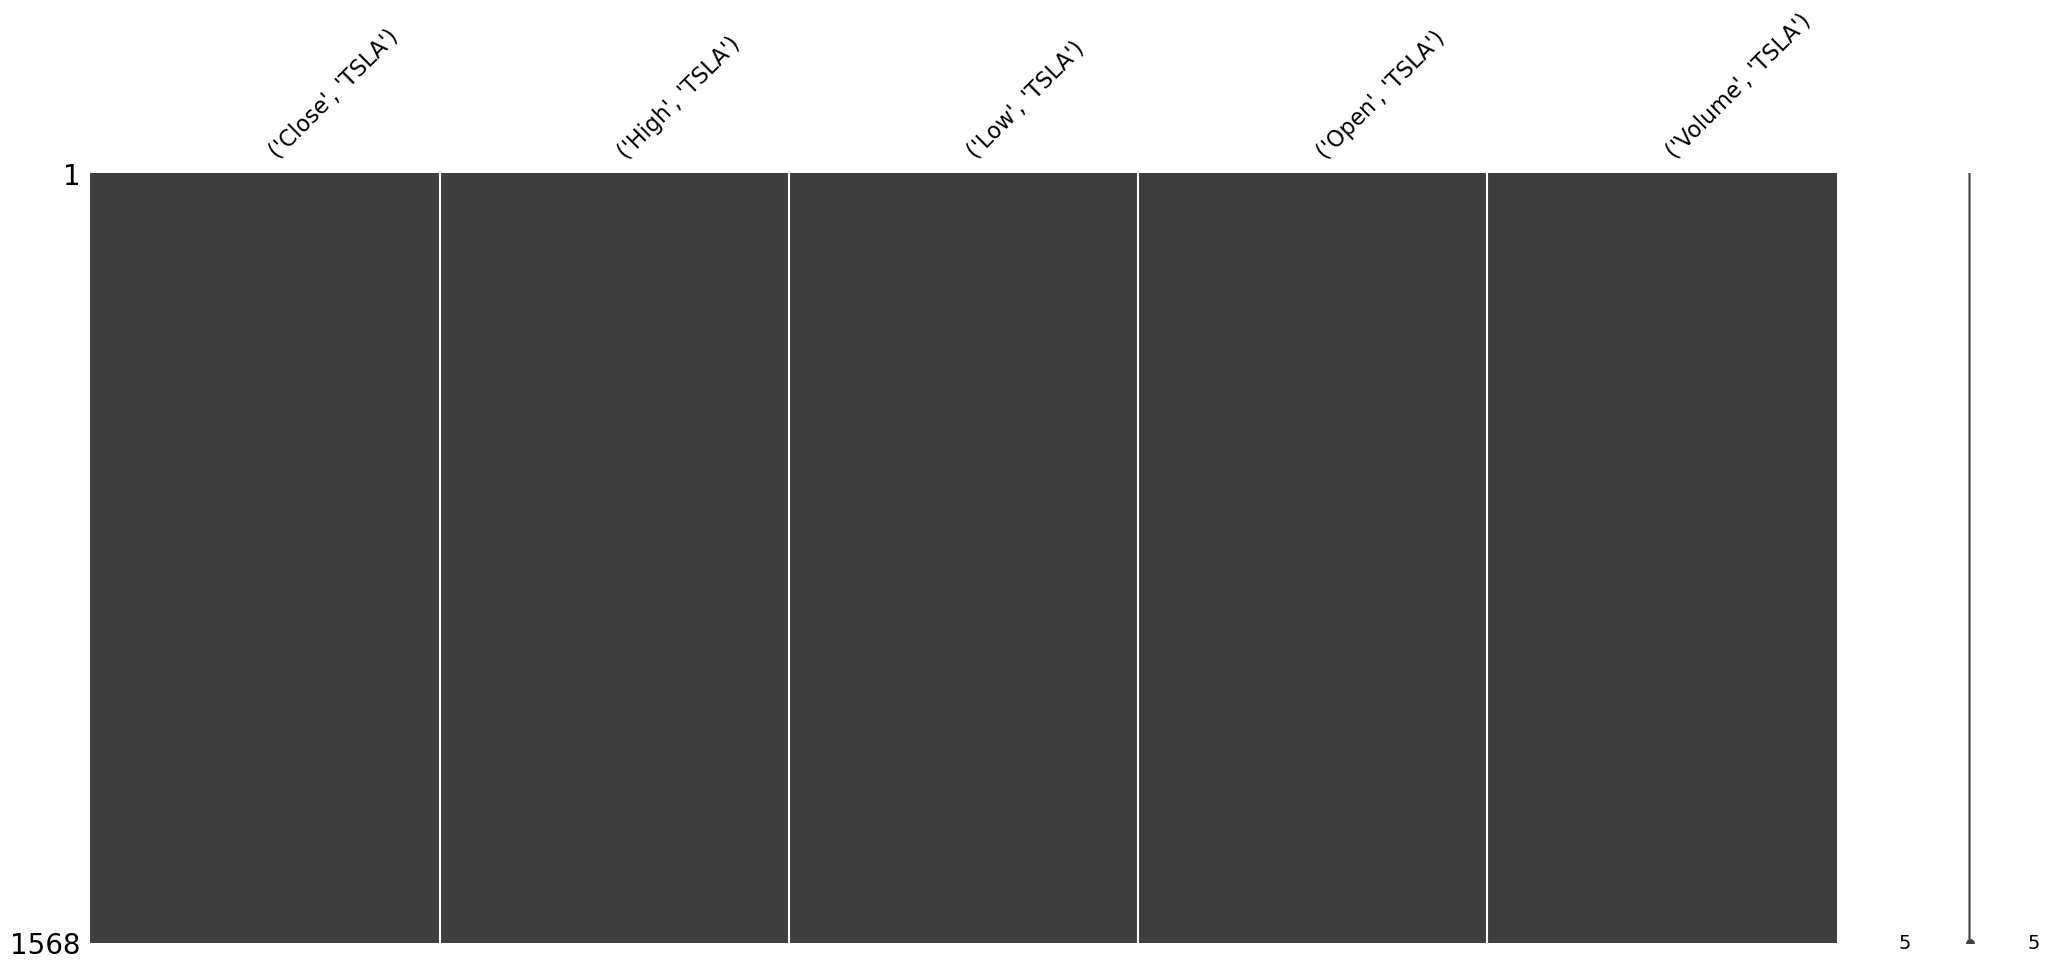

In [10]:
msno.matrix(tesla)

In [11]:
print('Data columns with null values:',tesla.isnull().sum(), sep = '\n')

Data columns with null values:
Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64


In [12]:
print(tesla.columns)

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


In [13]:
# Create target column (Next day's closing price)
tesla['Target'] = tesla['Close'].shift(-1)

In [14]:
tesla['Target'].value_counts()

Target
173.440002    2
284.820007    2
220.889999    2
272.040009    2
293.339996    2
             ..
403.320007    1
392.429993    1
405.940002    1
405.549988    1
35.861332     1
Name: count, Length: 1544, dtype: int64

In [15]:
tesla.fillna(method='ffill', inplace=True)

C:\Users\ASUS TUF A15\AppData\Local\Temp\ipykernel_14392\3745916787.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tesla.fillna(method='ffill', inplace=True)


In [16]:
print(tesla.isnull().sum())

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
Target            0
dtype: int64


In [17]:
from ydata_profiling import ProfileReport

tesla.columns = tesla.columns.get_level_values(0)


# Generate EDA report
profile = ProfileReport(
    tesla,
    title="TradeIQ - Stock Market Data Analysis Report",
    explorative=True
)

# Save report as HTML
profile.to_file("TradeIQ_EDA_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 321.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
tesla.columns = tesla.columns.get_level_values(0)

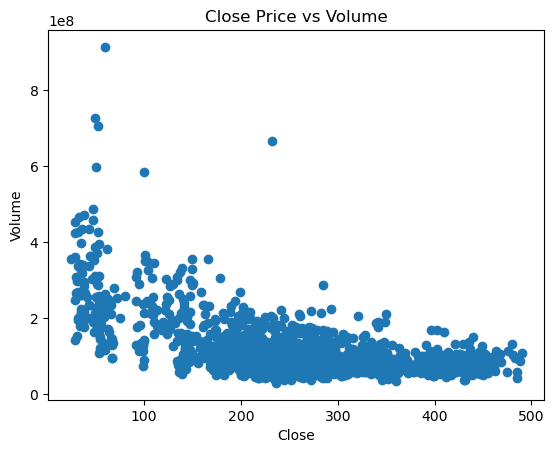

In [19]:
import matplotlib.pyplot as plt
plt.scatter(tesla["Close"], tesla["Volume"])
plt.title("Close Price vs Volume")
plt.xlabel("Close")
plt.ylabel("Volume")
plt.show()

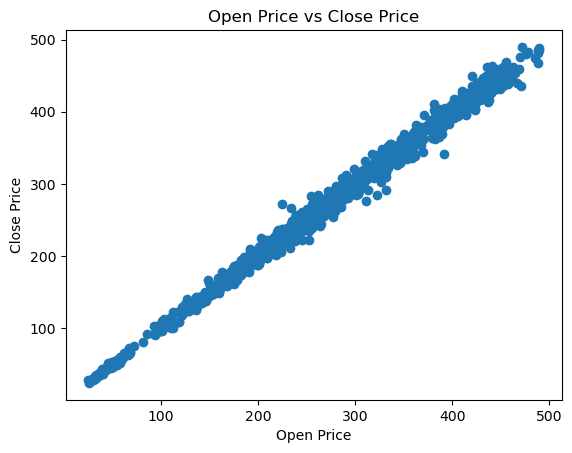

In [20]:
plt.scatter(tesla["Open"], tesla["Close"])
plt.title("Open Price vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

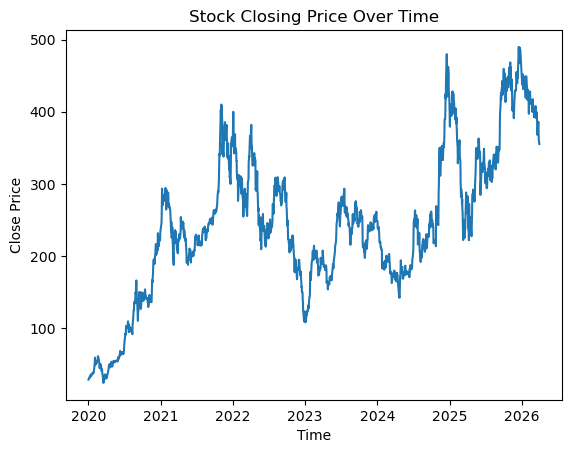

In [21]:
plt.plot(tesla["Close"])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.show()

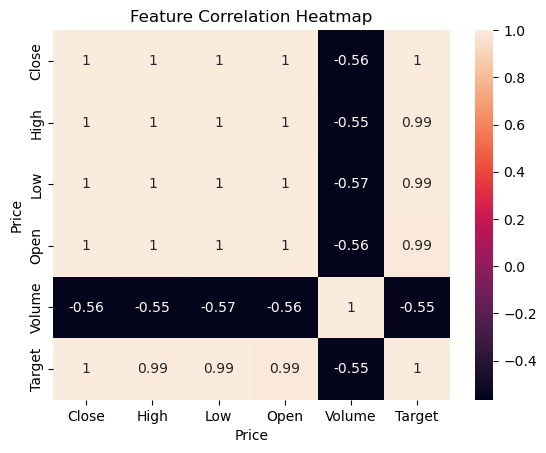

In [22]:
import seaborn as sns

sns.heatmap(tesla.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [23]:
# Fix column structure
tesla.columns = tesla.columns.get_level_values(0)

# Reset index (important)
tesla.reset_index(drop=True, inplace=True)

# Check
print(tesla.head())

Price      Close       High        Low       Open     Volume     Target
0      28.684000  28.713333  28.114000  28.299999  142981500  29.534000
1      29.534000  30.266666  29.128000  29.366667  266677500  30.102667
2      30.102667  30.104000  29.333332  29.364668  151995000  31.270666
3      31.270666  31.441999  30.224001  30.760000  268231500  32.809334
4      32.809334  33.232666  31.215334  31.580000  467164500  32.089333


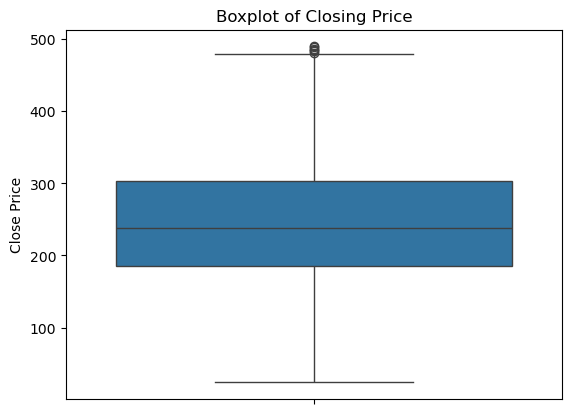

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=tesla["Close"])

plt.title("Boxplot of Closing Price")
plt.ylabel("Close Price")
plt.show()

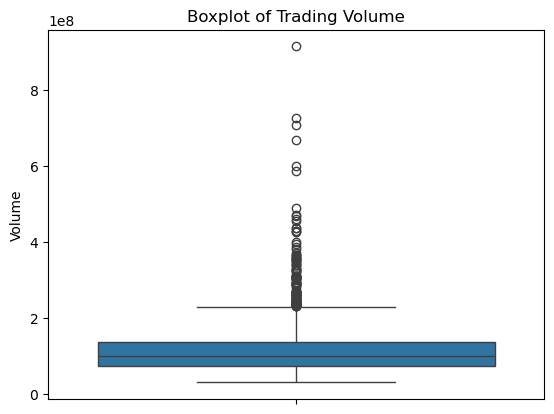

In [25]:
sns.boxplot(y=tesla["Volume"])

plt.title("Boxplot of Trading Volume")
plt.ylabel("Volume")
plt.show()

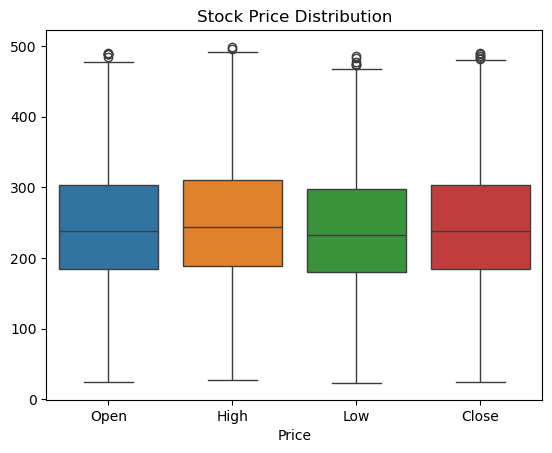

In [26]:
sns.boxplot(data=tesla[["Open", "High", "Low", "Close"]])

plt.title("Stock Price Distribution")
plt.show()

In [27]:
tesla.columns = tesla.columns.get_level_values(0)
tesla.reset_index(drop=True, inplace=True)

In [28]:
tesla['Trend'] = tesla['Close'].diff().apply(lambda x: 'Up' if x > 0 else 'Down')

In [29]:
import pandas as pd

tesla['Volume_Category'] = pd.qcut(tesla['Volume'], q=3, labels=['Low', 'Medium', 'High'])

In [30]:
df3 = pd.crosstab(tesla["Trend"], tesla["Volume_Category"])

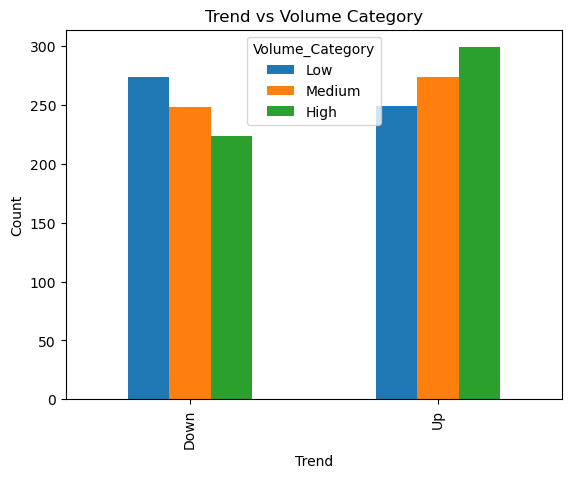

In [31]:
df3.plot(kind='bar')

plt.title("Trend vs Volume Category")
plt.xlabel("Trend")
plt.ylabel("Count")
plt.show()

In [32]:
# Create target
tesla['Target'] = tesla['Close'].shift(-1)

# Create classification label
tesla['Trend'] = tesla.apply(lambda row: 'Up' if row['Target'] > row['Close'] else 'Down', axis=1)

# Encode target
tesla['Trend'] = tesla['Trend'].map({'Down': 0, 'Up': 1})

# Remove NaN
tesla.dropna(inplace=True)

In [33]:
numeric_df = tesla.select_dtypes(include=['number'])

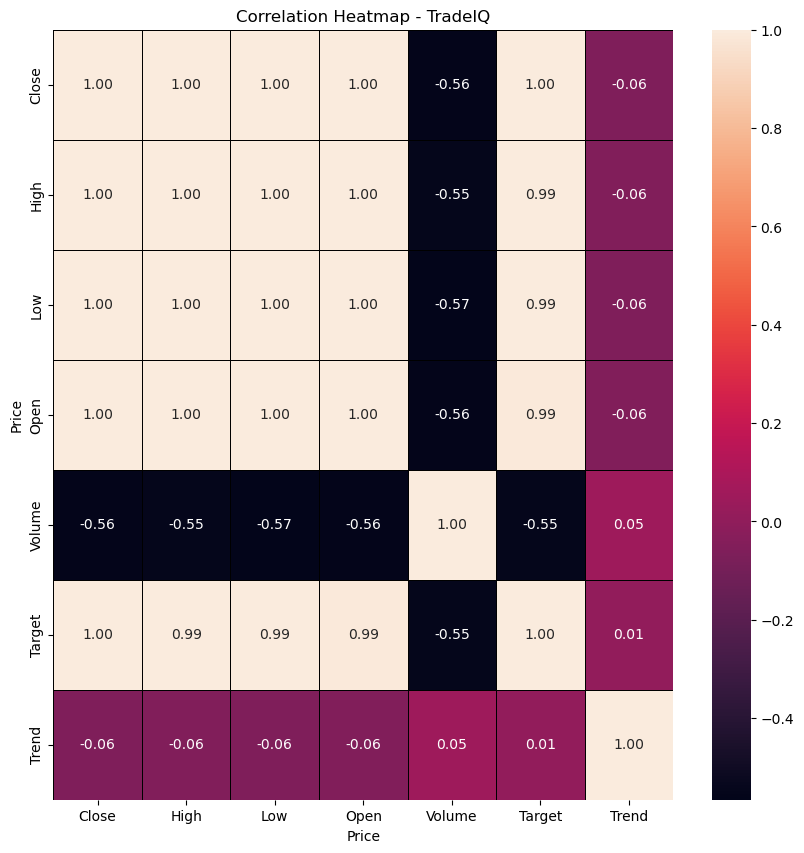

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    linewidths=0.5,
    linecolor="black",
    fmt=".2f",
    ax=ax
)

plt.title("Correlation Heatmap - TradeIQ")
plt.show()

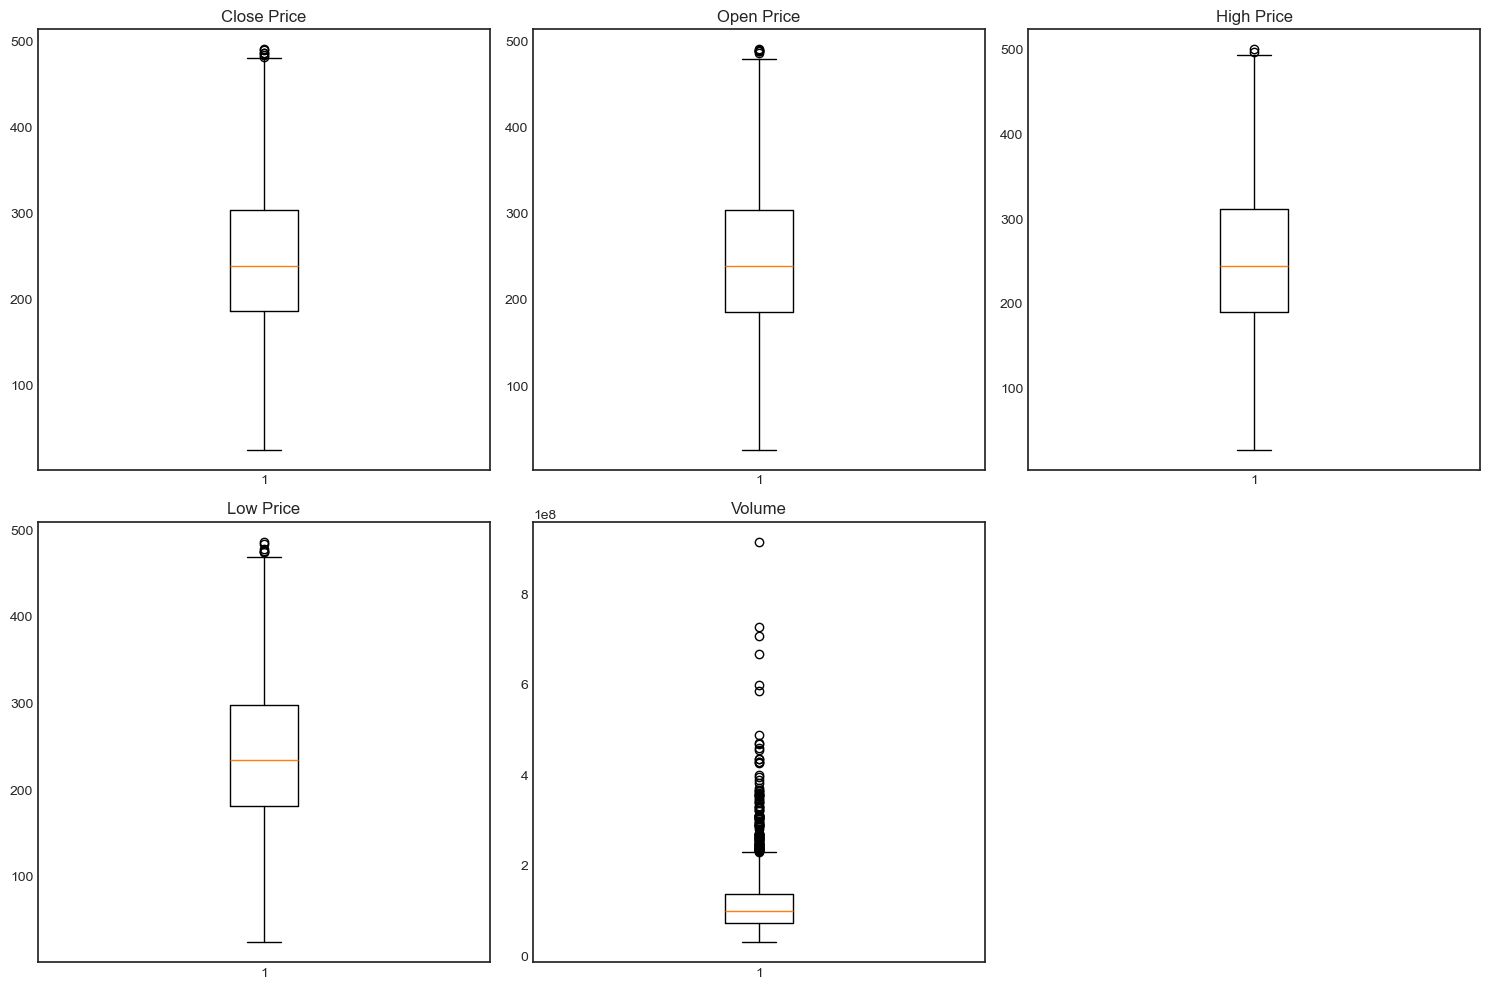

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.style.use('seaborn-v0_8-white')

# Close Price
ax = plt.subplot(231)
plt.boxplot(tesla['Close'])
ax.set_title('Close Price')

# Open Price
ax = plt.subplot(232)
plt.boxplot(tesla['Open'])
ax.set_title('Open Price')

# High Price
ax = plt.subplot(233)
plt.boxplot(tesla['High'])
ax.set_title('High Price')

# Low Price
ax = plt.subplot(234)
plt.boxplot(tesla['Low'])
ax.set_title('Low Price')

# Volume
ax = plt.subplot(235)
plt.boxplot(tesla['Volume'])
ax.set_title('Volume')

plt.tight_layout()
plt.show()

In [36]:
numerical_features = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numerical_features:
    Q1 = tesla[col].quantile(0.25)
    Q3 = tesla[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    tesla = tesla[(tesla[col] >= lower) & (tesla[col] <= upper)]

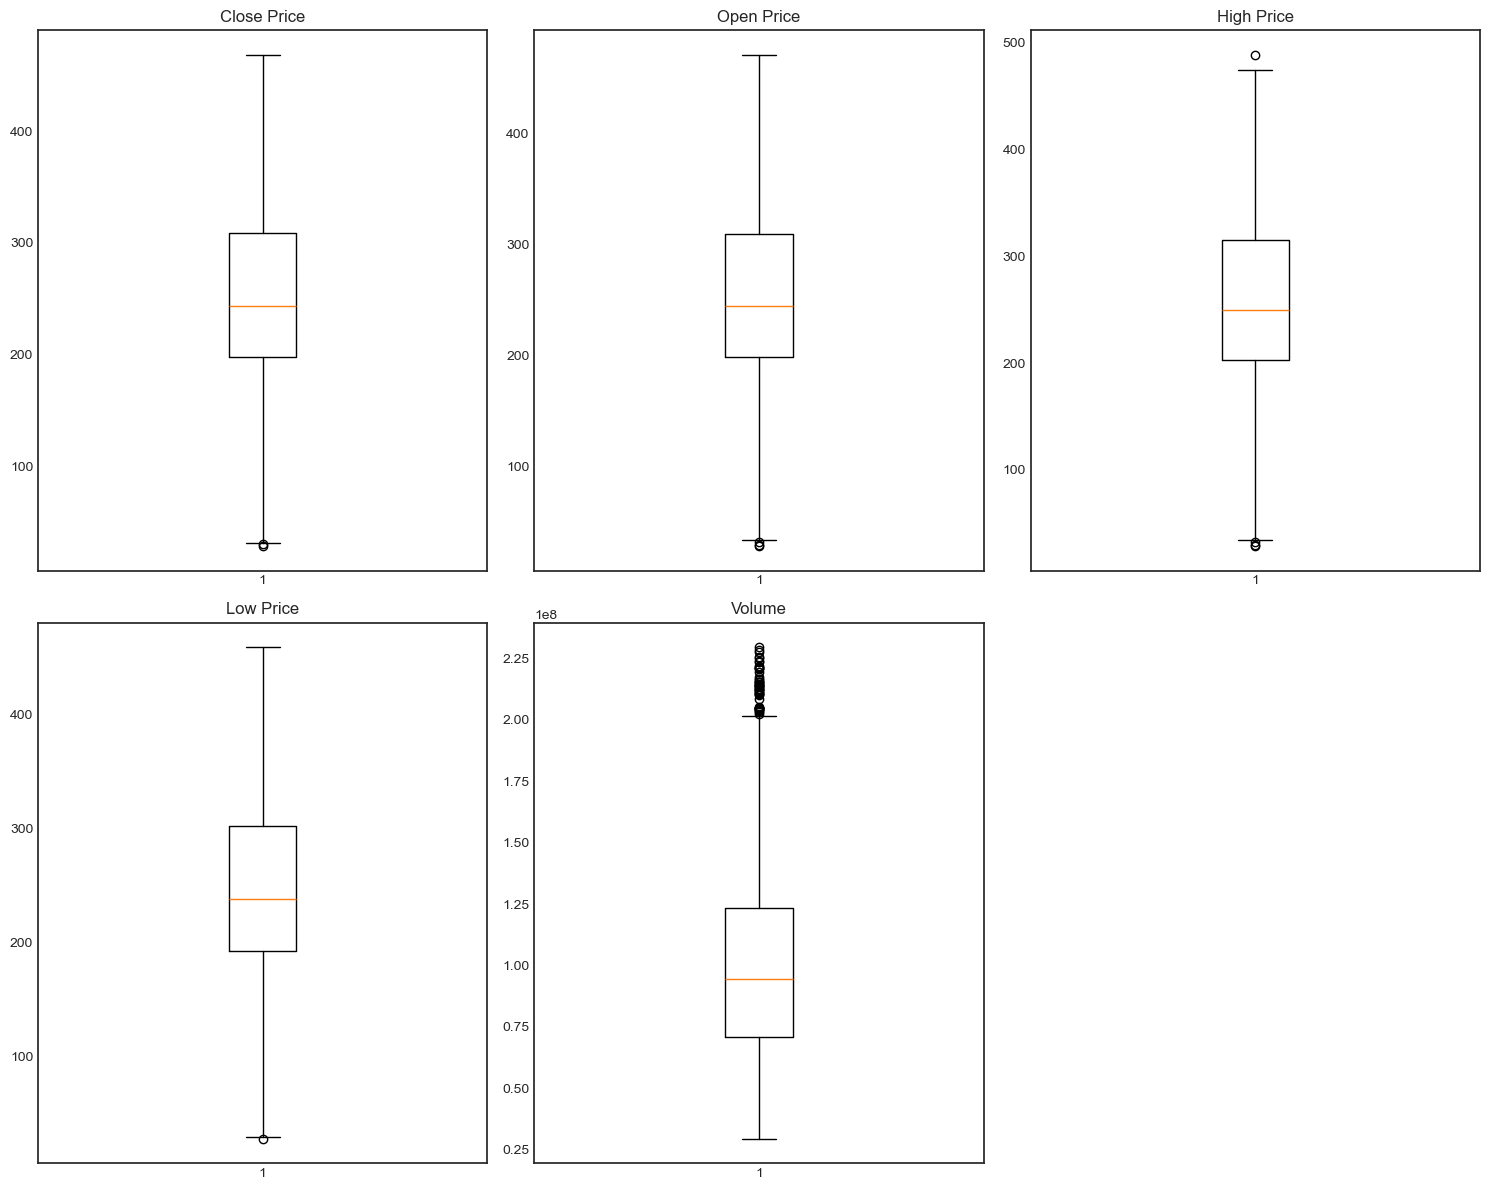

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
plt.style.use('seaborn-v0_8-white')

# Close Price
ax = plt.subplot(231)
plt.boxplot(tesla['Close'])
ax.set_title('Close Price')

# Open Price
ax = plt.subplot(232)
plt.boxplot(tesla['Open'])
ax.set_title('Open Price')

# High Price
ax = plt.subplot(233)
plt.boxplot(tesla['High'])
ax.set_title('High Price')

# Low Price
ax = plt.subplot(234)
plt.boxplot(tesla['Low'])
ax.set_title('Low Price')

# Volume
ax = plt.subplot(235)
plt.boxplot(tesla['Volume'])
ax.set_title('Volume')

plt.tight_layout()
plt.show()

In [38]:
tesla['Open_Close_Interaction'] = tesla['Open'] * tesla['Close']

In [39]:
tesla['High_Low_Interaction'] = tesla['High'] * tesla['Low']

In [40]:
tesla['Price_Volume_Interaction'] = tesla['Close'] * tesla['Volume']

In [41]:
tesla['Range_Volume'] = (tesla['High'] - tesla['Low']) * tesla['Volume']

In [42]:
# Interaction features
tesla['Open_Close_Interaction'] = tesla['Open'] * tesla['Close']
tesla['Price_Volume_Interaction'] = tesla['Close'] * tesla['Volume']
tesla['Range_Volume'] = (tesla['High'] - tesla['Low']) * tesla['Volume']

In [43]:
tesla.to_csv('TradeIQ_stock_data.csv', index=False)

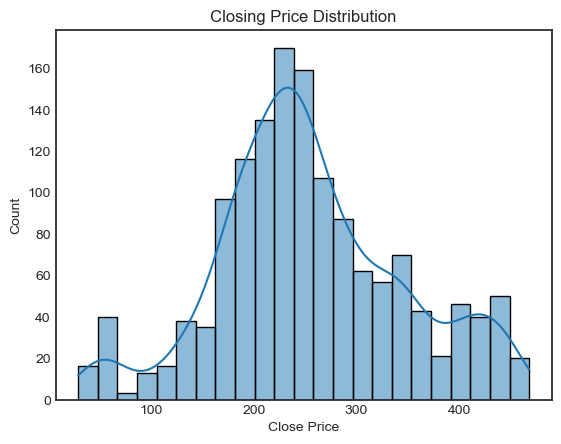

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(tesla['Close'], kde=True)

plt.title("Closing Price Distribution")
plt.xlabel("Close Price")
plt.show()

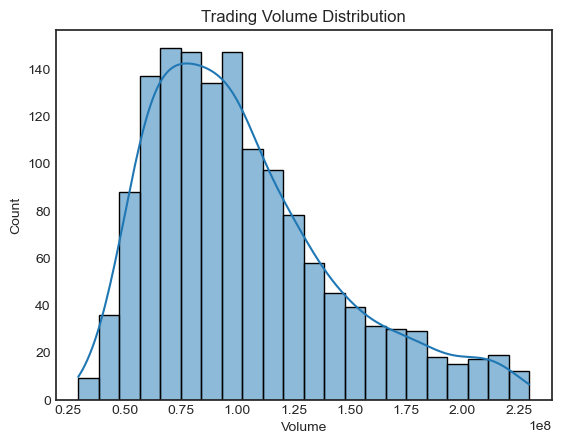

In [45]:
sns.histplot(tesla['Volume'], kde=True)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")
plt.show()

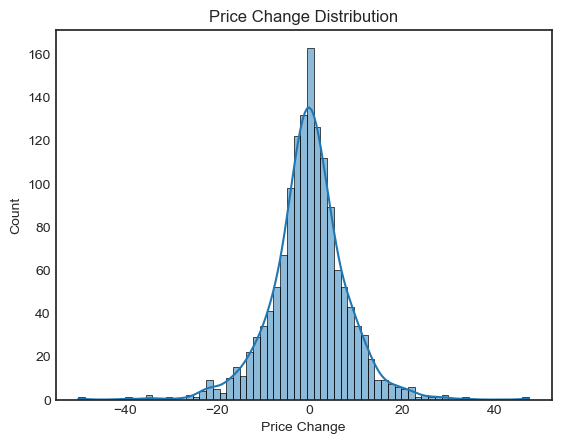

In [46]:
tesla['Price_Change'] = tesla['Close'] - tesla['Open']

sns.histplot(tesla['Price_Change'], kde=True)

plt.title("Price Change Distribution")
plt.xlabel("Price Change")
plt.show()

In [47]:
tesla['Price_Change'] = tesla['Close'] - tesla['Open']

tesla['Price_Change'].skew()

np.float64(-0.15992390359325417)

In [48]:
import numpy as np

tesla['Log_Volume'] = np.log1p(tesla['Volume'])

In [49]:
tesla['Price_Change'] = tesla['Close'] - tesla['Open']
tesla['Log_Price_Change'] = np.log1p(abs(tesla['Price_Change']))

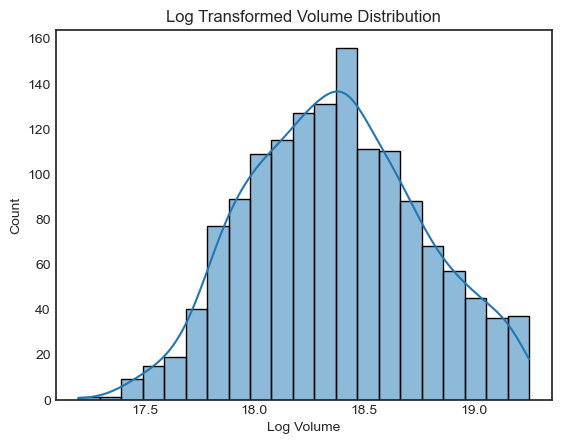

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(tesla['Log_Volume'], kde=True)

plt.title("Log Transformed Volume Distribution")
plt.xlabel("Log Volume")
plt.show()

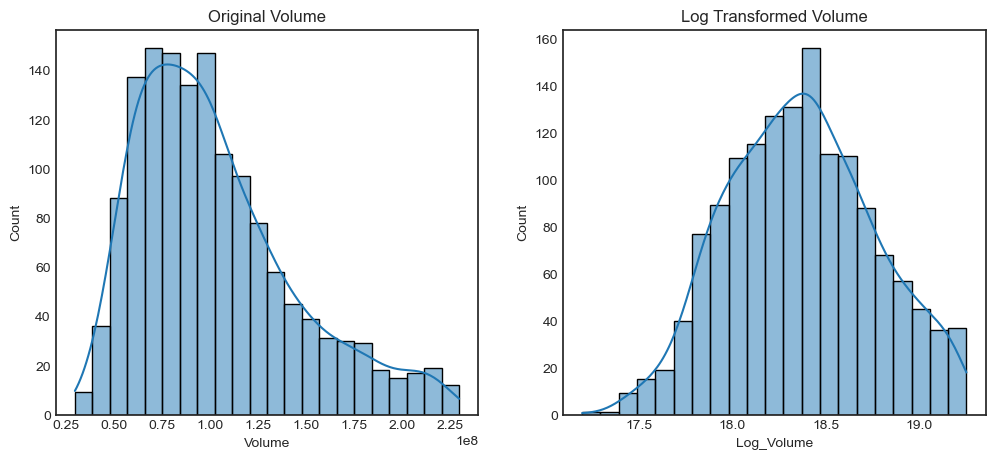

In [51]:
plt.figure(figsize=(12,5))

# Before
plt.subplot(1,2,1)
sns.histplot(tesla['Volume'], kde=True)
plt.title("Original Volume")

# After
plt.subplot(1,2,2)
sns.histplot(tesla['Log_Volume'], kde=True)
plt.title("Log Transformed Volume")

plt.show()

In [52]:
import numpy as np

tesla['Log_Volume'] = np.log1p(tesla['Volume'])

In [53]:
tesla['Log_Volume'].skew()

np.float64(0.0917713441677033)

In [54]:
print("Original Volume Skewness:", tesla['Volume'].skew())
print("Log Transformed Skewness:", tesla['Log_Volume'].skew())

Original Volume Skewness: 0.9320535664954074
Log Transformed Skewness: 0.0917713441677033


In [55]:
tesla.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1441 entries, 0 to 1566
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Close                     1441 non-null   float64 
 1   High                      1441 non-null   float64 
 2   Low                       1441 non-null   float64 
 3   Open                      1441 non-null   float64 
 4   Volume                    1441 non-null   int64   
 5   Target                    1441 non-null   float64 
 6   Trend                     1441 non-null   int64   
 7   Volume_Category           1441 non-null   category
 8   Open_Close_Interaction    1441 non-null   float64 
 9   High_Low_Interaction      1441 non-null   float64 
 10  Price_Volume_Interaction  1441 non-null   float64 
 11  Range_Volume              1441 non-null   float64 
 12  Price_Change              1441 non-null   float64 
 13  Log_Volume                1441 non-null   float64 
 1

In [56]:
cols_to_remove = tesla.iloc[:, [6,8,9,10,11,12,13,14]]

In [57]:
tesla.drop(columns=cols_to_remove.columns, inplace=True)

In [58]:
print(tesla.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Target', 'Volume_Category'], dtype='object', name='Price')


In [59]:
tesla.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1441 entries, 0 to 1566
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Close            1441 non-null   float64 
 1   High             1441 non-null   float64 
 2   Low              1441 non-null   float64 
 3   Open             1441 non-null   float64 
 4   Volume           1441 non-null   int64   
 5   Target           1441 non-null   float64 
 6   Volume_Category  1441 non-null   category
dtypes: category(1), float64(5), int64(1)
memory usage: 80.3 KB


In [60]:
from sklearn.model_selection import train_test_split

# Features (X) → all except Target
X = tesla.drop(['Target'], axis=1)

# Target (y)
y = tesla['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [61]:
tesla.columns = tesla.columns.get_level_values(0)
tesla.reset_index(drop=True, inplace=True)

In [62]:
print(X_train.dtypes)

Price
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Volume_Category    category
dtype: object


In [63]:
X = tesla.select_dtypes(include=['number'])

In [64]:
X = X.drop(['Target'], axis=1)   # or 'Trend' if classification
y = tesla['Target']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [66]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [67]:
ss = StandardScaler()
scaler = ss.fit(X_train)

In [68]:
x_train_scalled = ss.transform(X_train)
x_test_scalled = ss.transform(X_test)

In [69]:
x_train_scalled = pd.DataFrame(x_train_scalled, columns = X_train.columns)
x_test_scalled = pd.DataFrame(x_test_scalled, columns = X_test.columns)

In [70]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [71]:
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

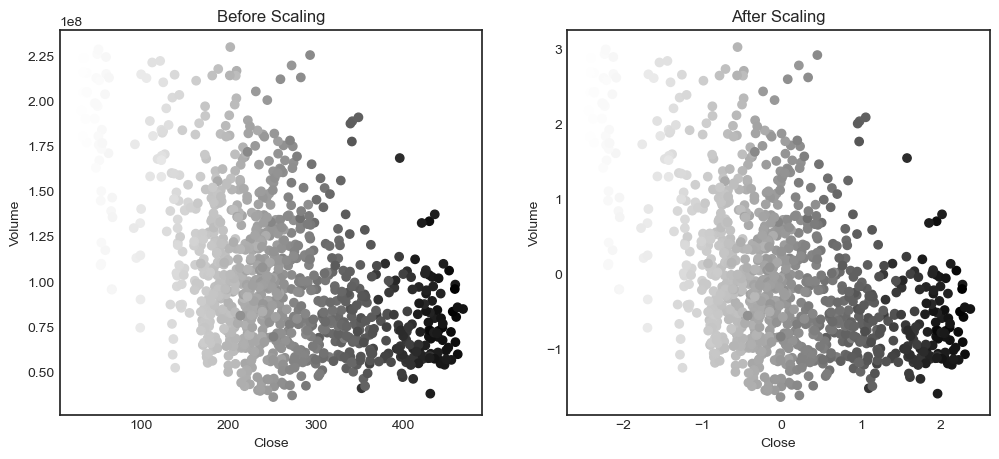

In [72]:
import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
a1.scatter(X_train["Close"], X_train["Volume"], c=y_train)
a1.set_title("Before Scaling")
a1.set_xlabel("Close")
a1.set_ylabel("Volume")

# After Scaling
a2.scatter(X_train_scaled["Close"], X_train_scaled["Volume"], c=y_train)
a2.set_title("After Scaling")
a2.set_xlabel("Close")
a2.set_ylabel("Volume")

plt.show()

In [73]:
tesla['Target'] = tesla['Close'].shift(-1)

tesla['Trend'] = tesla.apply(
    lambda row: 1 if row['Target'] > row['Close'] else 0,
    axis=1
)

tesla.dropna(inplace=True)

In [74]:
from scipy.stats import ttest_ind

Up = tesla[tesla['Trend'] == 1]['Close']
Down = tesla[tesla['Trend'] == 0]['Close']

In [75]:
t_stat, p_value = ttest_ind(Up, Down)

print("p-value:", p_value)

p-value: 0.06877011647213474


In [76]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(tesla['Close'], tesla['Volume'])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: -0.45438442676588686
p-value: 2.8336415452534625e-74


In [77]:
pearsonr(tesla['Open'], tesla['Close'])

PearsonRResult(statistic=np.float64(0.9960741001608725), pvalue=np.float64(0.0))

In [78]:
pearsonr(tesla['High'], tesla['Close'])

PearsonRResult(statistic=np.float64(0.9982824802875604), pvalue=np.float64(0.0))

In [79]:
tesla['Price_Change'] = tesla['Close'] - tesla['Open']

pearsonr(tesla['Price_Change'], tesla['Volume'])

PearsonRResult(statistic=np.float64(0.0591573363159175), pvalue=np.float64(0.024775850387352947))

In [80]:
import plotly.express as px

fig = px.scatter(
    tesla,
    x="Close",
    y="Volume",
    color="Trend",
    title="Close Price vs Volume (Interactive)",
    hover_data=["Open", "High", "Low"]
)

fig.show()

In [81]:
trend_counts = tesla['Trend'].value_counts().reset_index()
trend_counts.columns = ['Trend', 'Count']

In [82]:
import plotly.express as px

fig = px.bar(
    trend_counts,
    x='Trend',
    y='Count',
    color='Trend',
    title="Market Trend Distribution (Up vs Down)"
)

fig.show()

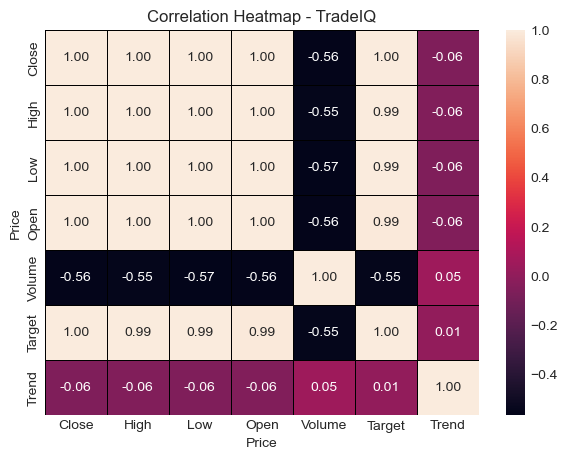

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(7,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    linewidths=0.5,
    linecolor="black",
    fmt=".2f",
    ax=ax
)

plt.title("Correlation Heatmap - TradeIQ")
plt.show()

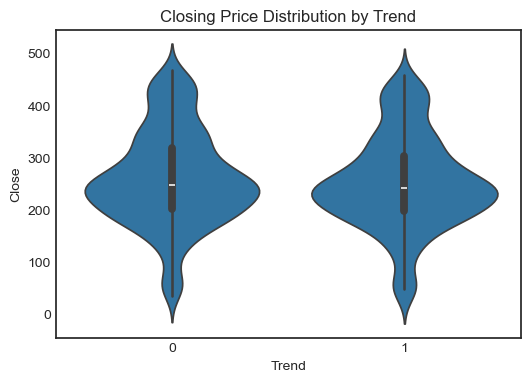

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.violinplot(
    x='Trend',
    y='Close',
    data=tesla
)

plt.title("Closing Price Distribution by Trend")
plt.show()

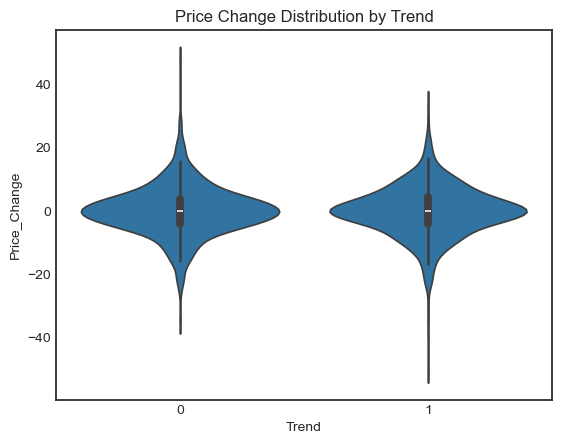

In [85]:
tesla['Price_Change'] = tesla['Close'] - tesla['Open']

sns.violinplot(
    x='Trend',
    y='Price_Change',
    data=tesla
)

plt.title("Price Change Distribution by Trend")
plt.show()

c:\Users\ASUS TUF A15\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\ASUS TUF A15\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



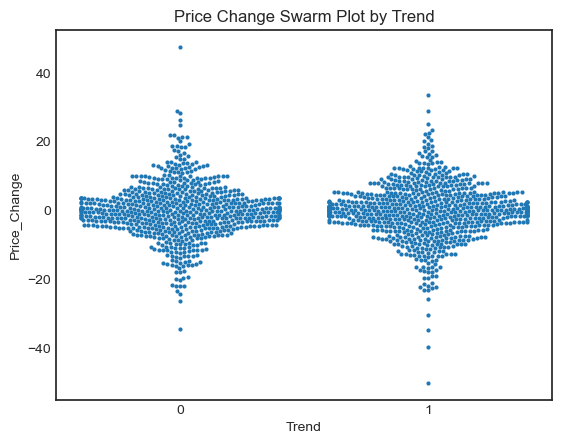

In [86]:
tesla['Price_Change'] = tesla['Close'] - tesla['Open']

sns.swarmplot(
    x='Trend',
    y='Price_Change',
    data=tesla,
    size=3
)

plt.title("Price Change Swarm Plot by Trend")
plt.show()

In [87]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = tesla[features]

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [89]:
from sklearn.cluster import AgglomerativeClustering

cluster_model = AgglomerativeClustering(n_clusters=3)

tesla['Cluster'] = cluster_model.fit_predict(X_scaled)

In [90]:
tesla.groupby('Cluster')[['Open','High','Low','Close','Volume']].mean()

Price,Open,High,Low,Close,Volume
Cluster,,,,,
0,344.294190,351.341708,336.588516,343.859800,8.380649e+07
1,212.161211,216.905484,207.286681,212.305828,1.067651e+08
2,76.991120,78.855044,75.137519,77.126804,1.767081e+08


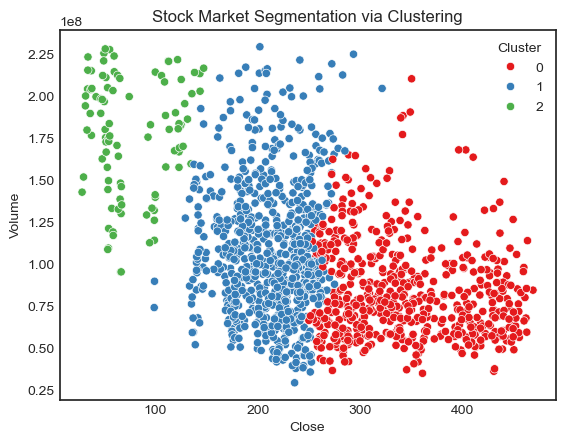

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='Close',
    y='Volume',
    hue='Cluster',
    data=tesla,
    palette='Set1'
)

plt.title("Stock Market Segmentation via Clustering")
plt.show()

In [92]:
tesla['Target'] = tesla['Close'].shift(-1)

tesla['Trend'] = tesla.apply(
    lambda row: 1 if row['Target'] > row['Close'] else 0,
    axis=1
)

In [93]:
tesla.dropna(inplace=True)

In [94]:
X = tesla.select_dtypes(include=['number']).drop(['Target','Trend'], axis=1)
y = tesla['Trend']   # ✅ NOT Target

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
from sklearn.linear_model import LogisticRegression

Logi_model = LogisticRegression()

Logi_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [98]:
from sklearn.metrics import accuracy_score

# Prediction
Logi_pred = Logi_model.predict(X_test_scaled)

# Accuracy (correct order: y_test first)
Logi_acc = accuracy_score(y_test, Logi_pred)

print("Accuracy:", Logi_acc)

Accuracy: 0.5046296296296297


In [99]:
# Features (input)
X = tesla[['Open', 'High', 'Low', 'Volume']]

# Target (next day price)
y = tesla['Target']

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [103]:
y_pred = model.predict(X_test_scaled)

In [104]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.9868041218204351
MSE: 102.50164871081553


In [105]:
# Features
X = tesla[['Open', 'High', 'Low', 'Volume']]

# Target
y = tesla['Trend']

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [108]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [109]:
y_pred = dt_model.predict(X_test_scaled)

In [110]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Detailed Report
print(classification_report(y_test, y_pred))

Accuracy: 0.4722222222222222
[[100 106]
 [122 104]]
              precision    recall  f1-score   support

           0       0.45      0.49      0.47       206
           1       0.50      0.46      0.48       226

    accuracy                           0.47       432
   macro avg       0.47      0.47      0.47       432
weighted avg       0.47      0.47      0.47       432



In [111]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [112]:
y_pred = rf_model.predict(X_test_scaled)

In [113]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.5115740740740741
[[107  99]
 [112 114]]
              precision    recall  f1-score   support

           0       0.49      0.52      0.50       206
           1       0.54      0.50      0.52       226

    accuracy                           0.51       432
   macro avg       0.51      0.51      0.51       432
weighted avg       0.51      0.51      0.51       432



In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [115]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [116]:
y_pred = knn_model.predict(X_test_scaled)

In [117]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.5162037037037037
[[112  94]
 [115 111]]
              precision    recall  f1-score   support

           0       0.49      0.54      0.52       206
           1       0.54      0.49      0.52       226

    accuracy                           0.52       432
   macro avg       0.52      0.52      0.52       432
weighted avg       0.52      0.52      0.52       432



In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf', random_state=42)

svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [120]:
y_pred = svc_model.predict(X_test_scaled)

In [121]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.49537037037037035
[[ 64 142]
 [ 76 150]]
              precision    recall  f1-score   support

           0       0.46      0.31      0.37       206
           1       0.51      0.66      0.58       226

    accuracy                           0.50       432
   macro avg       0.49      0.49      0.47       432
weighted avg       0.49      0.50      0.48       432



In [122]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Features
X = tesla[['Open', 'High', 'Low', 'Volume']]

# Target (next day price)
y = tesla['Target']

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-Validation R2 Scores:", scores)
print("Average R2 Score:", scores.mean())

Cross-Validation R2 Scores: [0.98982177 0.93397022 0.96365352 0.98130629 0.96398971]
Average R2 Score: 0.9665483048491387


In [123]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Use consistent features
features = ['Open', 'High', 'Low', 'Volume']

X = tesla[features]
y = tesla['Trend']

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # handle missing values
    ('scaler', StandardScaler()),                    # scale data
    ('regressor', LinearRegression())                # linear regression model
])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

joblib.dump(pipeline, 'tradeiq_linear_model.pkl')

model = joblib.load('tradeiq_linear_model.pkl')

R2 Score: -0.0018417624319004844
MSE: 0.24992361696126725


In [124]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [125]:
y_pred = pipeline.predict(X_test)

In [126]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.0018417624319004844
MSE: 0.24992361696126725
MAE: 0.4979731886565634


In [127]:
import pickle

model_path = "tradeiq_linear_pipeline.pkl"

with open(model_path, "wb") as file:
    pickle.dump(pipeline, file)

print("Model saved successfully at:", model_path)

Model saved successfully at: tradeiq_linear_pipeline.pkl


In [128]:
with open("tradeiq_linear_pipeline.pkl", "rb") as file:
    model = pickle.load(file)

print("Model loaded successfully")

Model loaded successfully
